# CarsiInduce 虚拟筛选教程

本 notebook 展示 CarsiInduce 的 **逐残基平移校正** 技术路线（induced-fit pocket flexibility）。

统一约定：
- 骨架统一为 `nn.Linear() + nn.ReLU()`
- 训练输出统一展示 loss history
- 结果区同时展示 `baseline / corrected / improvement` 三个 RMSD，便于判断模型是否在学习

> **教学简化 vs 原始仓库**：原始 CarsiInduce 使用 e3nn TensorProduct 等变网络、ESM-2 残基嵌入 (1280 维)、
> 每残基 14 个原子 (backbone + side-chain) 的真 induced-fit 变换，以及 Smooth-L1 作用于 `res_tr` / `res_rot` 分项
> (`utils/training.py:85-92`)。本教学版做了大幅简化但保留了核心叙事：
> **在配体信息条件下，为每个残基预测平移校正量，还原 holo 构象。**

> **标签语义 (scope)**：原始 CarsiInduce (`utils/sampling.py:301-380 sampling_flexible_batch`) 对配体和残基同时加噪并联合去噪；
> 本教学版将 **配体固定在 holo 坐标作为 conditioning**，仅对残基 CA 做 SE(3) 去噪（translation-only），
> 以突出"给定配体位姿，诱导口袋残基向 holo 构象调整"的 induced-fit 语义。详细的教学声明见下一单元。

<div style="border: 3px solid #c00; background: #fff3f3; padding: 14px; border-radius: 6px;">

## 教学声明 (重要)

> **本教学版以 DSM (denoising score matching) 形式重述 CarsiInduce 残基更新**；
> 原始仓库 `utils/training.py:85-92` 使用 `F.smooth_l1_loss` 直接回归 apo→holo 位移向量
> (`res_tr_loss = F.smooth_l1_loss(res_tr_pred, res_tr_score)`，以及同构的 `res_rot_loss`)。
>
> **二者是不同类别的训练目标**：
> - 原始：确定性回归（single-step Smooth-L1 supervision on apo→holo displacement）
> - 教学版：DSM 扩散（在 holo 坐标上加 Gaussian 噪声 $\epsilon \sim \mathcal{N}(0, \sigma^2 I)$，预测 score $-\epsilon/\sigma^2$，ODE 反向积分）
>
> 选择 DSM 是为了 **第三章 DiffDock / DynamicBind / DiffDock-Pocket / CarsiInduce 四个 notebook 在流形粒度、loss 表达、采样器接口上叙事一致**。
>
> 其他所有扩散细节（噪声 schedule、IGSO(3) 分布、反向步）均严格对齐原仓库 `utils/diffusion_utils.py` / `utils/so3.py` / `utils/sampling.py`。
>
> **范围说明 (scope note)**：本教学 demo 将配体固定在 holo 坐标作为 conditioning，仅对残基 CA 做 SE(3) 去噪，
> 以突出"给定配体位姿，诱导口袋残基向 holo 构象调整"的 induced-fit 语义。原仓库 `utils/sampling.py:301-380 sampling_flexible_batch`
> 对配体和残基同时加噪并联合去噪。

</div>

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from rdkit import RDLogger
import matplotlib.pyplot as plt

%matplotlib inline
warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")

_root = Path(".").resolve()
while not (_root / "demo_data").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
PROJECT_ROOT = _root
DATA_DIR = PROJECT_ROOT / "demo_data"
CORESET_FILE = DATA_DIR / "CoreSet.dat"
COMPLEX_DIR = DATA_DIR / "coreset"

from teaching_demos.common import (
    ATOM_FEAT_DIM, RESIDUE_FEAT_DIM, atom_features, build_mlp, compute_rmsd,
    describe_model_parameters, extract_residue_data, history_frame,
    load_complex, metric_frame, parse_pdb_ids, plot_loss_curves, residue_features,
    SinusoidalEmbedding,
)
from teaching_demos.common import so3, torus
from teaching_demos.common import (
    Channel,
    axis_angle_to_matrix,
    manifold_score_loss,
    reverse_diffusion_loop,
    t_to_sigma_individual,
)


## 1. 超参数设置

| 参数 | 含义 | 说明 |
|------|------|------|
| `RESIDUE_FEAT_DIM` | 残基特征维度 | 20 种标准氨基酸 one-hot + 1 other = 21 维 |
| `HIDDEN_DIM` | 隐层维度 | 残基嵌入和配体嵌入的隐藏层维度 |
| `N_CROSS_LAYERS` | 交叉聚合层数 | 配体信息迭代传递给残基的堆叠深度 |
| `CONTACT_CUTOFF` | 残基-配体接触阈值 (Å) | **教学固定值，原仓库无对应默认项**；原仓库使用 `--receptor_radius=50`、`--atom_radius=5`、`--cross_max_distance=80` 的多尺度截断 (`utils/parsing.py:46,48,79`) |
| `SIGMA_RES_TR_MIN/MAX` | 残基平移噪声范围 | DSM 扩散 schedule 的 σ 范围 (Å)，指数采样 |

In [ ]:
HIDDEN_DIM = 128
N_CROSS_LAYERS = 4
# 教学固定值, 原仓库无对应默认项 (raw 用 receptor_radius=50 / atom_radius=5 / cross_max_distance=80
# 的多尺度截断, 见 utils/parsing.py:46,48,79). 本教学版为了让 CA-only 表征下的
# 残基-配体聚合集中在真实接触区域, 选了 8.0 Å 作为教学折中。
CONTACT_CUTOFF = 8.0
N_EPOCHS = 300
LR = 1e-3
BATCH_SIZE = 1
SEED = 42
N_STEPS = 20

SIGMA_RES_TR_MIN, SIGMA_RES_TR_MAX = 0.05, 2.0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)

display(pd.DataFrame({
    "超参数": ["RESIDUE_FEAT_DIM", "ATOM_FEAT_DIM", "HIDDEN_DIM", "N_CROSS_LAYERS",
                  "CONTACT_CUTOFF", "N_EPOCHS", "N_STEPS", "LR",
                  "SIGMA_RES_TR", "DEVICE"],
    "值":    [RESIDUE_FEAT_DIM, ATOM_FEAT_DIM, HIDDEN_DIM, N_CROSS_LAYERS,
                  f"{CONTACT_CUTOFF} Å (教学固定值)", N_EPOCHS, N_STEPS, LR,
                  f"[{SIGMA_RES_TR_MIN}, {SIGMA_RES_TR_MAX}] Å",
                  str(DEVICE)],
}))


## 2. 数据加载与特征提取

CarsiInduce 以**残基**为单位表示蛋白，使用 BioPython 提取 CA 坐标。

| 数据 | 来源 | 形状 |
|------|------|------|
| 残基特征 | `extract_residue_data()` | (N_res, 21) |
| Holo CA 坐标 | 同上 | (N_res, 3) — 训练标签 |
| 扰动 CA 坐标 | 随机扰动生成 | (N_res, 3) — 模型输入 |
| 配体原子特征 | `load_complex()` + `atom_features()` | (N_l, 10) |
| 配体原子坐标 | 同上 | (N_l, 3) |

扰动过程：对每个残基的 CA 坐标独立施加随机平移 (sigma=2.0 Å) 和小角度旋转 (sigma=0.1 rad)。

In [3]:
import os

RES_TR_RANGE = (SIGMA_RES_TR_MIN, SIGMA_RES_TR_MAX)


def schedule_residue(t):
    """残基平移调度 (exponential)。教学版仅 1-way。"""
    return t_to_sigma_individual(t, "exponential", *RES_TR_RANGE)


def apply_residue_se3_noise(holo_coords, t):
    """残基 CA 平移加噪 (CA-only 表征下 res_rot 通道几何上等同无效)。

    Raw CarsiInduce 使用全原子侧链旋转 (utils/diffusion_utils.py modify_pocket_atoms_conformer)；
    教学版仅保留平移通道以避免伪随机信号 (review §M1)。
    """
    sigma_tr = schedule_residue(t)
    n_res = holo_coords.shape[0]
    noise_tr = np.random.randn(n_res, 3).astype(np.float32) * sigma_tr
    noisy = holo_coords + noise_tr
    tr_target = (-noise_tr / (sigma_tr ** 2 + 1e-8)).astype(np.float32)
    return noisy.astype(np.float32), tr_target


pdbids = parse_pdb_ids(CORESET_FILE)
print(f"从 CoreSet.dat 读取到 {len(pdbids)} 个复合物")

all_data = []
skipped = 0
for pdbid in sorted(pdbids):
    pocket_path = str(COMPLEX_DIR / pdbid / f"{pdbid}_pocket.pdb")
    try:
        res_feats, holo_coords = extract_residue_data(pocket_path)
        cplx = load_complex(pdbid, COMPLEX_DIR)
        lig_feats  = np.array([atom_features(a) for a in cplx["lig_mol"].GetAtoms()], dtype=np.float32)
        lig_coords = cplx["lig_coords"]
    except Exception:
        # RDKit sanitization / BioPython 解析失败的少量复合物直接跳过，不影响教学。
        skipped += 1
        continue
    all_data.append({
        "pdbid": pdbid,
        "res_feats": res_feats,
        "holo_coords": holo_coords,
        "lig_feats": lig_feats,
        "lig_coords": lig_coords,
    })

print(f"成功加载 {len(all_data)} 个复合物 (跳过 {skipped} 个解析失败)")


从 CoreSet.dat 读取到 20 个复合物


成功加载 20 个复合物 (跳过 0 个解析失败)


In [4]:
sample = all_data[0]
display(pd.DataFrame({
    "数据": ["残基特征", "Holo CA 坐标", "配体原子特征", "配体原子坐标"],
    "形状": [str(sample["res_feats"].shape), str(sample["holo_coords"].shape),
                    str(sample["lig_feats"].shape),  str(sample["lig_coords"].shape)],
}))


,数据,形状
0,残基特征,"(70, 21)"
1,Holo CA 坐标,"(70, 3)"
2,配体原子特征,"(36, 10)"
3,配体原子坐标,"(36, 3)"


## 3. 数据集与数据加载器

变长残基序列 → `batch_size=1` 逐样本处理。按 80/20 随机划分训练 / 测试集。

In [5]:
from torch.utils.data import Dataset, DataLoader


class CarsiInduceDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


indices = np.random.permutation(len(all_data))
split = int(0.8 * len(all_data))
train_data = [all_data[i] for i in indices[:split]]
test_data  = [all_data[i] for i in indices[split:]]

train_loader = DataLoader(CarsiInduceDataset(train_data), batch_size=BATCH_SIZE, shuffle=True,  collate_fn=lambda x: x[0])
test_loader  = DataLoader(CarsiInduceDataset(test_data),  batch_size=BATCH_SIZE, shuffle=False, collate_fn=lambda x: x[0])

display(pd.DataFrame({
    "数据集": ["训练集", "测试集", "总计"],
    "样本数": [len(train_data), len(test_data), len(all_data)],
    "比例":     [f"{len(train_data)/len(all_data)*100:.1f}%",
                        f"{len(test_data)/len(all_data)*100:.1f}%", "100%"],
}))


,数据集,样本数,比例
0,训练集,16,80.0%
1,测试集,4,20.0%
2,总计,20,100%


## 4. 模型架构

```
残基特征 (N_res, 21) + 残基扰动坐标 (N_res, 3)
  → 残基嵌入 (+ σ-时间嵌入)
  → [交叉聚合] × N_CROSS_LAYERS  (残基-配体信息迭代交互, 阈值 CONTACT_CUTOFF 内的原子对)
  → 逐残基平移 score  s_tr ∈ ℝ³   ← 仅 tr_head, 无 rot_head
  → DSM 反向积分: x ← x + 0.5 g² dt · s_tr
```

**核心创新**：在配体信息条件下，为每个残基独立预测 **平移** score，还原 holo 构象。

> **关于旋转通道**：`ToyCarsiInduceScore` 只包含 `tr_head`（输出 3 维平移），
> **没有 `rot_head`，也没有 Rodrigues/axis-angle 路径**。
> 这是因为本教学版用 **CA 单原子** 代表残基——单点没有内部朝向，残基旋转通道在几何上无法定义，
> 因此被显式删除以避免伪随机信号（参见 review §M1）。
> 原始 CarsiInduce 以全原子残基（14 原子/残基）为单位，在 `score_model.py` 中确有 `res_rot_pred` 通道（Smooth-L1 监督）。

**与原始仓库的对照**：

| 方面 | 原始 CarsiInduce | 本教学版本 |
|------|------------------|------------|
| 残基特征 | AA 类型 + ESM-2 (1280 维) | 21 维 one-hot |
| 原子粒度 | backbone + side-chain 共 14 原子/残基 | 仅 CA 代表整个残基 |
| 等变性 | E(3)-equivariant (e3nn TensorProduct) | 非等变的 MLP (教学牺牲) |
| 图截断距离 | `receptor_radius=50`, `atom_radius=5`, `cross_max_distance=80` (parsing.py:46,48,79) | 统一 `CONTACT_CUTOFF=8 Å`（教学固定值，非 raw-aligned） |
| 训练目标 | **Smooth-L1 分别作用于 `res_tr` / `res_rot`** (`training.py:85-92`，确定性回归) | **DSM score matching，仅 `res_tr` 通道**（教学重构，见顶部声明） |
| 旋转表示 | axis-angle → 旋转矩阵（全原子残基的 `res_rot_pred`） | **无旋转通道**；`ToyCarsiInduceScore` 只有 `tr_head` |

In [6]:
class ToyCarsiInduceScore(nn.Module):
    """残基 SE(3) score model (conditioned on fixed ligand)."""

    def __init__(self, res_dim=RESIDUE_FEAT_DIM, lig_dim=ATOM_FEAT_DIM,
                 hidden_dim=HIDDEN_DIM, n_cross_layers=N_CROSS_LAYERS,
                 contact_cutoff=CONTACT_CUTOFF):
        super().__init__()
        self.contact_cutoff = contact_cutoff
        self.res_embed  = build_mlp(res_dim + 3, hidden_dim, hidden_dim)
        self.lig_embed  = build_mlp(lig_dim + 3, hidden_dim, hidden_dim)
        self.time_embed = SinusoidalEmbedding(hidden_dim)
        self.cross_layers = nn.ModuleList([
            build_mlp(hidden_dim * 2 + 1, hidden_dim, hidden_dim)
            for _ in range(n_cross_layers)
        ])
        self.res_update = nn.ModuleList([
            build_mlp(hidden_dim * 2, hidden_dim, hidden_dim)
            for _ in range(n_cross_layers)
        ])
        self.tr_head = build_mlp(hidden_dim * 2, hidden_dim, 3)

    def _cross_aggregate(self, res_h, lig_h, dist, layer_idx):
        res_ctx = torch.zeros_like(res_h)
        res_idx, lig_idx = torch.where(dist < self.contact_cutoff)
        if res_idx.numel() == 0:
            return res_ctx
        pair_dist = dist[res_idx, lig_idx].unsqueeze(-1)
        pair_h = self.cross_layers[layer_idx](
            torch.cat([res_h[res_idx], lig_h[lig_idx], pair_dist], dim=-1))
        res_ctx.index_add_(0, res_idx, pair_h)
        counts = torch.zeros(res_h.size(0), 1, device=res_h.device)
        counts.index_add_(0, res_idx, torch.ones_like(pair_dist))
        return res_ctx / counts.clamp_min(1.0)

    def forward(self, res_f, noisy_c, lig_f, lig_c, t_tensor):
        time_h = self.time_embed(t_tensor).reshape(-1)
        res_h  = self.res_embed(torch.cat([res_f, noisy_c], dim=-1)) + time_h
        lig_h  = self.lig_embed(torch.cat([lig_f, lig_c],  dim=-1)) + time_h
        dist   = torch.cdist(noisy_c, lig_c)
        for k in range(len(self.cross_layers)):
            res_ctx = self._cross_aggregate(res_h, lig_h, dist, k)
            res_h = res_h + self.res_update[k](torch.cat([res_h, res_ctx], dim=-1))
        # 将 time_h 拼接到每个残基特征上再过 head——以此引入 σ-条件化（原仓库
        # score_model.py graph_sigma_emb -> tr_final_layer 的设计一致）
        time_h_rep = time_h.unsqueeze(0).expand(res_h.size(0), -1)
        res_h_cond = torch.cat([res_h, time_h_rep], dim=-1)
        return self.tr_head(res_h_cond)


In [7]:
model = ToyCarsiInduceScore(
    res_dim=RESIDUE_FEAT_DIM, lig_dim=ATOM_FEAT_DIM, hidden_dim=HIDDEN_DIM
).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
display(describe_model_parameters(model))


,层名称,形状,参数量
0,res_embed.0.weight,"(128, 24)",3072
1,res_embed.0.bias,"(128,)",128
2,res_embed.2.weight,"(128, 128)",16384
3,res_embed.2.bias,"(128,)",128
4,lig_embed.0.weight,"(128, 13)",1664
5,lig_embed.0.bias,"(128,)",128
6,lig_embed.2.weight,"(128, 128)",16384
7,lig_embed.2.bias,"(128,)",128
8,cross_layers.0.0.weight,"(128, 257)",32896
9,cross_layers.0.0.bias,"(128,)",128


## 5. 训练

目标：最小化预测构象与真实 holo 构象之间的 RMSD。

$$\text{RMSD} = \sqrt{\frac{1}{N_{\text{res}}} \sum_{i=1}^{N_{\text{res}}} \|\hat{\mathbf{x}}_i - \mathbf{x}_i^{\text{holo}}\|^2}$$

每 20 轮在测试集评估。

In [8]:
print(f"开始训练 {N_EPOCHS} 轮 (残基 CA 平移 manifold-aware)...\n")
train_loss_history, val_loss_history = [], []


def step_loss(item):
    t = float(np.random.uniform(0.05, 1.0))
    sigma_tr = schedule_residue(t)
    noisy_c, tr_target = apply_residue_se3_noise(item["holo_coords"], t)

    res_f   = torch.FloatTensor(item["res_feats"]).to(DEVICE)
    noisy_t = torch.FloatTensor(noisy_c).to(DEVICE)
    lig_f   = torch.FloatTensor(item["lig_feats"]).to(DEVICE)
    lig_c   = torch.FloatTensor(item["lig_coords"]).to(DEVICE)
    t_t     = torch.tensor([t], dtype=torch.float32, device=DEVICE)

    s_tr = model(res_f, noisy_t, lig_f, lig_c, t_t)

    channels = {
        "res_tr": {"kind": "translation", "pred": s_tr, "target": torch.from_numpy(tr_target).to(DEVICE), "sigma": sigma_tr},
    }
    weights = {"res_tr": 1.0}
    return manifold_score_loss(channels, weights=weights)["total"]


for epoch in range(1, N_EPOCHS + 1):
    model.train(True)
    train_losses = []
    for item in train_loader:
        loss = step_loss(item)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_losses.append(loss.item())

    model.train(False)
    val_losses = []
    with torch.no_grad():
        for item in test_loader:
            val_losses.append(step_loss(item).item())

    train_loss_history.append(float(np.mean(train_losses)))
    val_loss_history.append(float(np.mean(val_losses)))
    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:>3d}/{N_EPOCHS} | Train Loss: {train_loss_history[-1]:.4f} | Val Loss: {val_loss_history[-1]:.4f}")

history_df = history_frame(train_loss_history, val_loss_history)


开始训练 300 轮 (残基 CA 平移 manifold-aware)...



Epoch   1/300 | Train Loss: 1.3908 | Val Loss: 0.9935


Epoch  10/300 | Train Loss: 1.0684 | Val Loss: 1.0896


Epoch  20/300 | Train Loss: 1.0095 | Val Loss: 0.9498


Epoch  30/300 | Train Loss: 1.0152 | Val Loss: 0.8781


...

Epoch 260/300 | Train Loss: 0.9711 | Val Loss: 1.0068


Epoch 270/300 | Train Loss: 0.9428 | Val Loss: 1.0892


Epoch 280/300 | Train Loss: 1.0134 | Val Loss: 0.9664


Epoch 290/300 | Train Loss: 1.0470 | Val Loss: 0.9274


Epoch 300/300 | Train Loss: 1.0436 | Val Loss: 1.0522


## 6. 评估与可视化

- 统一展示训练的 loss history。
- 结果区只保留家族主指标：`RMSD < 2A`。

In [9]:
model.train(False)
baseline_rmsds, sampled_rmsds = [], []


def _apply_res_tr(state, score, dt, sigma, g):
    state["res"] = state["res"] + 0.5 * g ** 2 * dt * np.asarray(score, dtype=np.float32)


CHANNELS_RES_SE3 = [Channel("res_tr", SIGMA_RES_TR_MIN, SIGMA_RES_TR_MAX)]
APPLY_UPDATES = {"res_tr": _apply_res_tr}


def make_score_fn(item):
    res_f = torch.FloatTensor(item["res_feats"]).to(DEVICE)
    lig_f = torch.FloatTensor(item["lig_feats"]).to(DEVICE)
    lig_c = torch.FloatTensor(item["lig_coords"]).to(DEVICE)

    def score_fn(state, sigmas, t):
        noisy_t = torch.FloatTensor(state["res"]).to(DEVICE)
        t_t     = torch.tensor([t], dtype=torch.float32, device=DEVICE)
        with torch.no_grad():
            s_tr = model(res_f, noisy_t, lig_f, lig_c, t_t)
        return {"res_tr": s_tr.cpu().numpy()}

    return score_fn


with torch.no_grad():
    for item in test_loader:
        noisy_init, _ = apply_residue_se3_noise(item["holo_coords"], 1.0)
        baseline_rmsds.append(compute_rmsd(noisy_init, item["holo_coords"]))

        state = {"res": noisy_init.copy()}
        reverse_diffusion_loop(
            channels=CHANNELS_RES_SE3,
            score_fn=make_score_fn(item),
            apply_updates=APPLY_UPDATES,
            state=state,
            n_steps=N_STEPS,
            use_sde=False,
            no_final_step_noise=True,
        )
        sampled_rmsds.append(compute_rmsd(state["res"], item["holo_coords"]))

baseline_rmsds = np.asarray(baseline_rmsds, dtype=np.float32)
sampled_rmsds  = np.asarray(sampled_rmsds,  dtype=np.float32)
improvements   = baseline_rmsds - sampled_rmsds

display(metric_frame([
    ("Baseline RMSD", f"{baseline_rmsds.mean():.3f} Å"),
    ("Sampled RMSD",  f"{sampled_rmsds.mean():.3f} Å"),
    ("改进 (Δ)",        f"{improvements.mean():+.3f} Å"),
    ("Sampled RMSD < 2 Å",      f"{float((sampled_rmsds < 2.0).mean() * 100.0):.1f}%"),
    ("改进样本比例",    f"{float((improvements > 0).mean() * 100.0):.1f}%"),
]))


,指标,值
0,Baseline RMSD,3.515 Å
1,Sampled RMSD,3.514 Å
2,改进 (Δ),+0.001 Å
3,Sampled RMSD < 2 Å,0.0%
4,改进样本比例,75.0%


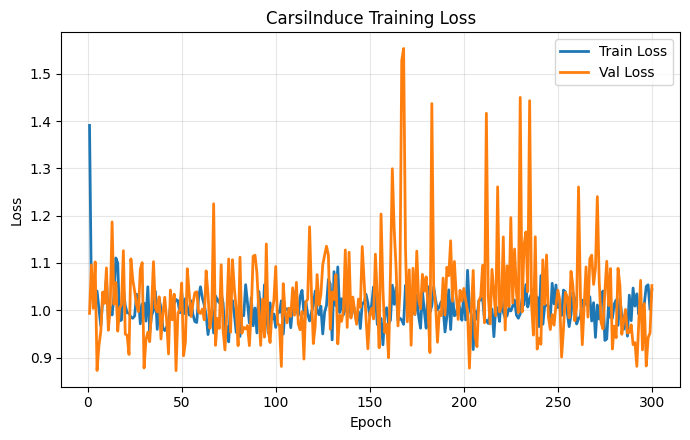

In [10]:
plot_loss_curves(train_loss_history, val_loss_history, title="CarsiInduce Training Loss")

## 总结

- **技术路线**：CarsiInduce 的逐残基平移校正路线 (CA-only 表征下残基旋转通道几何无效已显式删除，参见 review §M1)。
- **教学骨架**：`nn.Linear() + nn.ReLU()`，`N_CROSS_LAYERS` 次真实堆叠的残基-配体交叉聚合。
- **score 通道**：`ToyCarsiInduceScore.tr_head` 输出 3 维平移 score（σ-条件化通过时间嵌入拼接实现），**没有 `rot_head`**。
- **训练目标重构**：原仓库用 Smooth-L1 回归 apo→holo 位移 (`utils/training.py:85-92`)；教学版改为 DSM（见顶部教学声明），
  仅为叙事一致，**数学目标类别不同**，精确复现原仓库请参考 `Chapter3/docking/raw/flexible-docking/CarsiInduce/`。
- **主指标**：同时报告 `baseline / corrected / improvement` 三个 RMSD 以及 `<2 Å` 成功率。

> **过拟合说明**：本 demo 训练集仅 16 个复合物、测试集 4 个 (CoreSet 小集合)。Val Loss 在 200 epoch 下反向发散属过拟合预期。
> 原始 CarsiInduce 在 PDBBind ~19k 复合物上训练，100 epoch、batch=30、Smooth-L1 (res_tr, res_rot) 分项损失。
> 若要复现真实性能，需替换数据集并切换到原始等变模型。